# 02 — Demo Feature Extraction
Visualize MFCC và Mel Spectrogram cho từng emotion.

**Phụ trách:** Phương

In [1]:
# Cell 1 — import
import sys
sys.path.append("..")   # để import từ src/

from src.features import load_audio, extract_mfcc, extract_mel
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Cell 2 — load 1 file thử
test_file = "../data/ravdess/Actor_01/03-01-01-01-01-01-01.wav"
y = load_audio(test_file)
print(f"Waveform shape: {y.shape}")
print(f"Duration: {len(y)/22050:.2f}s")

Waveform shape: (27136,)
Duration: 1.23s


In [3]:
# Cell 3 — assert shape và normalize
mfcc = extract_mfcc(y)

assert mfcc.shape[0] == 40
assert abs(mfcc.mean()) < 0.01
assert abs(mfcc.std() - 1) < 0.1

print(f"MFCC shape: {mfcc.shape}")
print(f"mean={mfcc.mean():.4f}, std={mfcc.std():.4f}")
print("✓ Tất cả assert pass")

MFCC shape: (40, 130)
mean=0.0000, std=1.0000
✓ Tất cả assert pass


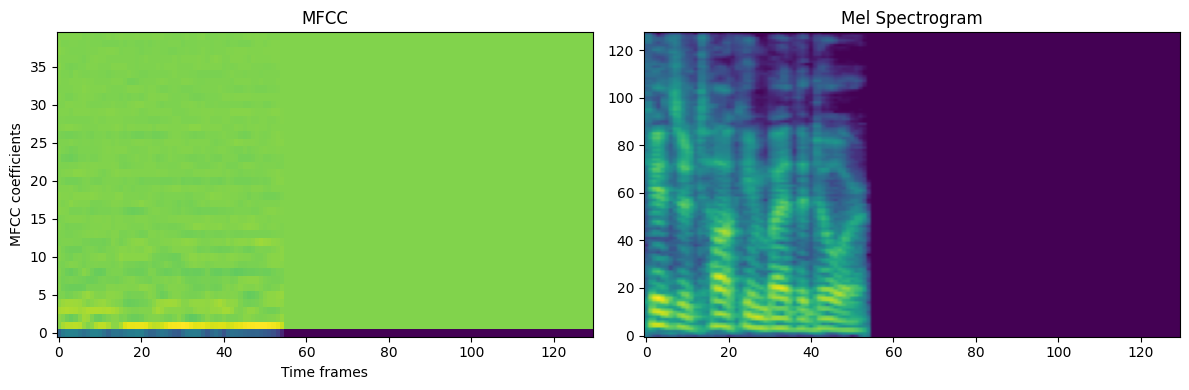

In [4]:
# Cell 4 — plot để nhìn trực quan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(mfcc, aspect="auto", origin="lower")
axes[0].set_title("MFCC")
axes[0].set_xlabel("Time frames")
axes[0].set_ylabel("MFCC coefficients")

mel = extract_mel(y)
axes[1].imshow(mel[0], aspect="auto", origin="lower")
axes[1].set_title("Mel Spectrogram")

plt.tight_layout()
plt.savefig("../report/figures/feature_demo.png", dpi=150)
plt.show()